# Notebook 02 — Data Cleaning

**Purpose:** Take the raw Brooklyn PLUTO subset, document the column schema, diagnose data-quality issues (missing values, zero-value 'hidden missing', invalid coordinates, outliers), apply principled filters, and produce a clean dataset suitable for feature engineering.

**Inputs:**
- `data/processed/brooklyn_pluto.parquet` — Brooklyn subset of PLUTO 25v4 (produced by Notebook 01)

**Outputs:**
- `data/processed/brooklyn_clean.parquet` — cleaned and filtered Brooklyn buildings, ready for feature engineering
- In-notebook data quality report (markdown summary for the final project report)

**Downstream dependencies:** `03_feature_engineering.ipynb` consumes `brooklyn_clean.parquet`.

**Author:** Delfin Aksu — Urban Building ML class project

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_ROOT = Path('..').resolve()
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

BROOKLYN_LAT_RANGE = (40.55, 40.74)
BROOKLYN_LON_RANGE = (-74.05, -73.83)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: C:\Users\Delfin AKSU\Desktop\urban-building-ml


## 2. Load Brooklyn PLUTO

Read the Brooklyn subset that was filtered and saved in Notebook 01. PLUTO 25v4 ships 92 columns covering tax-lot identification, building physical characteristics, zoning, land use, ownership, and assessed values.

In [3]:
brooklyn_path = PROCESSED_DATA_DIR / 'brooklyn_pluto.parquet'
assert brooklyn_path.exists(), f'Missing input: {brooklyn_path}. Run Notebook 01 first.'

df = pd.read_parquet(brooklyn_path)
print(f'Loaded brooklyn_pluto.parquet: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded brooklyn_pluto.parquet: 276,324 rows x 92 columns


### 2.1 Quick structural inspection

In [4]:
df.head(3)

,borough,block,lot,cd,bct2020,bctcb2020,ct2010,cb2010,schooldist,council,zipcode,firecomp,policeprct,healthcenterdistrict,healtharea,sanitboro,sanitdistrict,sanitsub,address,zonedist1,zonedist2,zonedist3,zonedist4,overlay1,overlay2,spdist1,spdist2,spdist3,ltdheight,splitzone,bldgclass,landuse,easements,ownertype,ownername,lotarea,bldgarea,comarea,resarea,officearea,retailarea,garagearea,strgearea,factryarea,otherarea,areasource,numbldgs,numfloors,unitsres,unitstotal,lotfront,lotdepth,bldgfront,bldgdepth,ext,proxcode,irrlotcode,lottype,bsmtcode,assessland,assesstot,exempttot,yearbuilt,yearalter1,yearalter2,histdist,landmark,builtfar,residfar,commfar,facilfar,borocode,bbl,condono,tract2010,xcoord,ycoord,zonemap,zmcode,sanborn,taxmap,edesignum,appbbl,appdate,plutomapid,firm07_flag,pfirm15_flag,version,dcpedited,latitude,longitude,notes
0,BK,748,12,307.0,3009600.0,3.009600e+10,96.0,4001.0,15.0,38.0,11220.0,E201,72.0,39.0,6600.0,3.0,7.0,3D,520 45 STREET,R6B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,C0,2.0,0.0,NaN,"CHEN, YI-CHUN",2003.0,3060.0,0.0,3060.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,3.0,3.0,3.0,20.00,100.17,20.00,58.0,N,3.0,N,5.0,2.0,31620.0,99180.0,0.0,1920.0,0.0,0.0,NaN,NaN,1.53,2.00,0.0,2.0,3,3.007480e+09,NaN,96.0,982295.0,175145.0,22a,NaN,306A028,30304.0,NaN,NaN,NaN,1,NaN,NaN,25v4,NaN,40.647409,-74.007045,NaN
1,BK,640,42,307.0,3014500.0,3.014500e+10,145.0,4001.0,15.0,38.0,11215.0,L122,72.0,39.0,4400.0,3.0,7.0,2C,688 5 AVENUE,R6A,NaN,NaN,NaN,C2-4,NaN,NaN,NaN,NaN,NaN,N,S2,4.0,0.0,NaN,688 5TH AVENUE LLC,1408.0,2520.0,832.0,1688.0,0.0,832.0,0.0,0.0,0.0,0.0,2.0,1.0,3.0,2.0,3.0,21.83,64.50,21.83,40.0,E,0.0,N,5.0,2.0,11460.0,141360.0,0.0,1932.0,0.0,0.0,NaN,NaN,1.79,3.00,0.0,3.0,3,3.006400e+09,NaN,145.0,986060.0,180319.0,16d,NaN,306 020,30301.0,NaN,NaN,NaN,1,NaN,NaN,25v4,NaN,40.661611,-73.993476,NaN
2,BK,5884,48,310.0,3003400.0,3.003400e+10,34.0,3000.0,20.0,47.0,11209.0,E241,68.0,31.0,7600.0,3.0,10.0,1E,97A 71 STREET,R3-2,NaN,NaN,NaN,NaN,NaN,BR,NaN,NaN,NaN,N,A5,1.0,0.0,NaN,DONALD SULLIVAN,1169.0,1142.0,0.0,1142.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,15.58,75.00,15.50,48.5,N,3.0,N,5.0,2.0,8580.0,56040.0,1420.0,1935.0,0.0,0.0,NaN,NaN,0.98,0.75,0.0,1.0,3,3.058840e+09,NaN,34.0,975175.0,170924.0,22a,NaN,311 018,31802.0,NaN,NaN,NaN,1,NaN,NaN,25v4,NaN,40.635819,-74.032697,NaN


In [5]:
df.dtypes.value_counts()

float64    60
str        28
int64       4
Name: count, dtype: int64

In [6]:
df.dtypes.to_frame('dtype')

,dtype
borough,str
block,int64
lot,int64
cd,float64
bct2020,float64
...,...
version,str
dcpedited,str
latitude,float64
longitude,float64


## 3. Schema Decisions

PLUTO 25v4 ships 92 columns. The majority are administrative bookkeeping that carry no signal for property-value prediction or urban-pattern discovery. Carrying all 92 forward would inflate memory and dilute schema documentation in the final report.

### 3.1 Kept columns by group

| Group | Columns | Why kept |
|---|---|---|
| Identifier & metadata | `bbl`, `borough`, `block`, `lot`, `address`, `zipcode`, `cd` | Primary key, debug, aggregation keys. |
| Geography | `latitude`, `longitude` | Source-of-truth coordinates. |
| Classification | `bldgclass`, `landuse` | DOF building class and land-use category. |
| Physical | `lotarea`, `bldgarea`, `comarea`, `resarea`, `numbldgs`, `numfloors`, `unitsres`, `unitstotal` | Core building geometry and unit counts. |
| Age | `yearbuilt`, `yearalter1` | Drives `building_age`. |
| Assessed values | `assessland`, `assesstot`, `exempttot` | `assesstot` is the regression target. |
| Misc signal | `builtfar`, `firm07_flag` | Cross-check for FAR; flood-zone indicator. |

### 3.2 Dropped columns by group

| Group | Reason |
|---|---|
| Admin districts (`schooldist`, `council`, `firecomp`, `policeprct`, `sanit*`, `healtharea`, `healthcenterdistrict`) | Government-service bookkeeping; no causal link beyond `cd`/`zipcode`. |
| Zoning detail (`zonedist1`–`4`, `overlay1`–`2`, `spdist1`–`3`, `ltdheight`, `splitzone`) | High-cardinality noise; `landuse` summarises the signal. |
| Ownership (`ownername`, `ownertype`, `easements`) | Identity is not a building feature. |
| Sub-area breakdowns (`officearea`, `retailarea`, `garagearea`, `strgearea`, `factryarea`, `otherarea`, `areasource`) | PLUTO leaves blank; totals carry signal. |
| Lot/building geometry detail (`lotfront`, `lotdepth`, `bldgfront`, `bldgdepth`, `ext`, `proxcode`, `irrlotcode`, `lottype`, `bsmtcode`) | Derivative of `lotarea`/`bldgarea`. |
| Other admin IDs (`borocode`, `condono`, `tract2010`, `zonemap`, `zmcode`, `sanborn`, `taxmap`, `edesignum`, `appbbl`, `appdate`, `plutomapid`, `version`, `dcpedited`, `notes`, `pfirm15_flag`, `histdist`, `landmark`, `yearalter2`, `bct2020`, `bctcb2020`, `ct2010`, `cb2010`, `residfar`, `commfar`, `facilfar`) | PLUTO bookkeeping or superseded variants. |

### 3.3 Apply the schema decision

In [7]:
KEEP_COLUMNS = [
    'bbl', 'borough', 'block', 'lot', 'address', 'zipcode', 'cd',
    'latitude', 'longitude',
    'bldgclass', 'landuse',
    'lotarea', 'bldgarea', 'comarea', 'resarea',
    'numbldgs', 'numfloors', 'unitsres', 'unitstotal',
    'yearbuilt', 'yearalter1',
    'assessland', 'assesstot', 'exempttot',
    'builtfar', 'firm07_flag',
]

missing = [c for c in KEEP_COLUMNS if c not in df.columns]
assert not missing, f'KEEP_COLUMNS references columns not in df: {missing}'

df = df[KEEP_COLUMNS].copy()
print(f'After schema reduction: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Dropped {92 - df.shape[1]} bookkeeping / redundant columns.')

After schema reduction: 276,324 rows x 26 columns
Dropped 66 bookkeeping / redundant columns.


## 4. Missing-Value Analysis

We inspect every kept column for true `NaN` / `None` values. This is distinct from zero-value 'hidden missing' (covered in Section 5).

### 4.1 Missing-value table

In [8]:
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False)
missing_report

,missing_count,missing_pct
firm07_flag,268909,97.32
comarea,12250,4.43
resarea,12250,4.43
numfloors,11041,4.00
landuse,1255,0.45
zipcode,572,0.21
latitude,480,0.17
cd,470,0.17
longitude,480,0.17
builtfar,356,0.13


### 4.2 Buckets of missingness

In [9]:
buckets = {
    'No missing (0%)':         missing_report[missing_report['missing_pct'] == 0].index.tolist(),
    'Trivial (0-1%)':           missing_report[(missing_report['missing_pct'] > 0) & (missing_report['missing_pct'] <= 1)].index.tolist(),
    'Moderate (1-10%)':         missing_report[(missing_report['missing_pct'] > 1) & (missing_report['missing_pct'] <= 10)].index.tolist(),
    'Heavy (10-50%)':           missing_report[(missing_report['missing_pct'] > 10) & (missing_report['missing_pct'] <= 50)].index.tolist(),
    'Mostly missing (>50%)':    missing_report[missing_report['missing_pct'] > 50].index.tolist(),
}

for label, cols in buckets.items():
    print(f'{label}: {len(cols)} columns')
    if cols:
        for c in cols:
            print(f'    - {c}: {missing_report.loc[c, "missing_pct"]:.2f}%')

No missing (0%): 4 columns
    - lot: 0.00%
    - block: 0.00%
    - bbl: 0.00%
    - borough: 0.00%
Trivial (0-1%): 18 columns
    - landuse: 0.45%
    - zipcode: 0.21%
    - latitude: 0.17%
    - cd: 0.17%
    - longitude: 0.17%
    - builtfar: 0.13%
    - numbldgs: 0.10%
    - lotarea: 0.10%
    - unitstotal: 0.06%
    - unitsres: 0.06%
    - bldgarea: 0.04%
    - address: 0.03%
    - bldgclass: 0.03%
    - yearbuilt: 0.03%
    - assessland: 0.03%
    - yearalter1: 0.03%
    - exempttot: 0.03%
    - assesstot: 0.03%
Moderate (1-10%): 3 columns
    - comarea: 4.43%
    - resarea: 4.43%
    - numfloors: 4.00%
Heavy (10-50%): 0 columns
Mostly missing (>50%): 1 columns
    - firm07_flag: 97.32%


### 4.3 Interpretation of the missing-value patterns

- **Identifier columns are complete.** `bbl`, `borough`, `block`, `lot` have 0% missing.
- **A correlated 92-row block of bad records.** `address`, `bldgclass`, `yearbuilt`, `assessland`, `yearalter1`, `exempttot`, `assesstot` all show exactly 92 missing values — the same 92 records. PLUTO placeholder entries. Filtered in Section 7.
- **480 records with missing coordinates** — removed by coordinate sanity check.
- **`firm07_flag` is sparse by design** (97.32% missing = "not in a FEMA flood zone"). Converted to binary in Notebook 03.
- **`comarea` / `resarea` jointly missing in 4.43%.** Tree-based models handle NaN natively; left as-is.
- **`numfloors` missing in 4.00%.** NaN for tree models; median-imputed only in linear baseline.

**Heavy (10–50%) bucket is empty.** No systematic medium-grade gaps.

## 5. Zero-Value (Hidden-Missing) Analysis

PLUTO encodes several unknown values as `0` rather than `NaN`. `pandas.isna()` does not catch these.

### 5.1 Zero-value counts

In [10]:
zero_checks = ['yearbuilt', 'bldgarea', 'lotarea', 'assesstot', 'unitstotal', 'numfloors', 'yearalter1']
zero_rows = []
for col in zero_checks:
    zero_count = (df[col] == 0).sum()
    zero_rows.append({'column': col, 'zero_count': int(zero_count), 'zero_pct': round(zero_count / len(df) * 100, 2)})
zero_report = pd.DataFrame(zero_rows).set_index('column').sort_values('zero_pct', ascending=False)
zero_report

,zero_count,zero_pct
column,,
yearalter1,239403,86.64
unitstotal,11128,4.03
yearbuilt,10240,3.71
bldgarea,10250,3.71
assesstot,970,0.35
lotarea,59,0.02
numfloors,0,0.00


### 5.2 Overlap between zero-value patterns

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

overlap = pd.DataFrame({
    'bldgarea_zero':   df['bldgarea'] == 0,
    'lotarea_zero':    df['lotarea'] == 0,
    'assesstot_zero':  df['assesstot'] == 0,
    'yearbuilt_zero':  df['yearbuilt'] == 0,
})

print(f'Rows with at least one zero among (bldgarea, lotarea, assesstot, yearbuilt): {overlap.any(axis=1).sum():,}')
print(f'Rows with ALL FOUR zero:                                                   {overlap.all(axis=1).sum():,}')

# Co-occurrence correlation matrix as a heatmap
corr_matrix = overlap.astype(int).corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson correlation'},
    annot_kws={'size': 13, 'weight': 'bold'},
    linewidths=0.8,
    linecolor='white',
    ax=ax,
)
ax.set_title('Co-occurrence of zero-value patterns',
             fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Rows with at least one zero: 11,090
Rows with ALL FOUR zero:     54

Co-occurrence counts:
                bldgarea_zero  lotarea_zero  assesstot_zero  yearbuilt_zero
bldgarea_zero        1.000000      0.069214        0.209155        0.941511
lotarea_zero         0.069214      1.000000        0.242032        0.074494
assesstot_zero       0.209155      0.242032        1.000000        0.213152
yearbuilt_zero       0.941511      0.074494        0.213152        1.000000


### 5.3 Findings and treatment decisions

- **`yearalter1` is 86.6% zero** — canonical 'never altered'. Kept.
- **`bldgarea_zero` and `yearbuilt_zero` are 0.94 correlated.** ~10,250 vacant lots. One filter eliminates both.
- **`assesstot == 0`** in 970 rows (0.35%) — tax-exempt. Filtered.
- **`lotarea == 0`** in 59 rows — corrupt. Filtered.
- **`unitstotal == 0`** in 11,128 rows — legitimate non-residential. Kept.
- **`numfloors` has zero zeros** — uses NaN-only encoding.

## 6. Coordinate Sanity Check

Brooklyn buildings must have lat in [40.55, 40.74] and lon in [−74.05, −73.83]. Diagnostic only; removal happens in Section 7.

### 6.1 Build the coordinate validity mask

In [12]:
coord_status = pd.Series('valid', index=df.index, name='coord_status')
lat_null = df['latitude'].isna()
lon_null = df['longitude'].isna()
lat_out = (df['latitude'] < BROOKLYN_LAT_RANGE[0]) | (df['latitude'] > BROOKLYN_LAT_RANGE[1])
lon_out = (df['longitude'] < BROOKLYN_LON_RANGE[0]) | (df['longitude'] > BROOKLYN_LON_RANGE[1])

coord_status[lat_null | lon_null] = 'null'
coord_status[(~(lat_null | lon_null)) & (lat_out | lon_out)] = 'out_of_bbox'

coord_status.value_counts()

coord_status
valid    275844
null        480
Name: count, dtype: int64

### 6.2 Where exactly do the out-of-bbox rows sit?

In [13]:
oob = df.loc[coord_status == 'out_of_bbox', ['bbl', 'address', 'latitude', 'longitude']]
if len(oob) > 0:
    print(f'Out-of-bbox sample (showing up to 10):')
    print(oob.head(10).to_string())
else:
    print('No coordinates outside the Brooklyn bounding box.')

No coordinates outside the Brooklyn bounding box.


### 6.3 Findings

- `valid` = 275,844 (99.83%)
- `null`  = 480 (matches Section 4 missing-coords count)
- `out_of_bbox` = 0 — PLUTO geocoding is internally consistent.

## 7. Audited Filter Pipeline

**Step order:**

1. Recode `yearbuilt == 0` to `NaN` (no row dropped)
2. Drop invalid coordinates
3. Drop `bldgarea <= 0` or NaN
4. Drop `lotarea <= 0` or NaN
5. Drop `assesstot <= 0` or NaN

### 7.1 Step 1 — Recode hidden missing

In [14]:
recode_log = []
yb_zero_n = int((df['yearbuilt'] == 0).sum())
df['yearbuilt'] = df['yearbuilt'].replace(0, np.nan)
recode_log.append({'column': 'yearbuilt', 'rule': 'replace 0 with NaN', 'rows_affected': yb_zero_n})
pd.DataFrame(recode_log)

,column,rule,rows_affected
0,yearbuilt,replace 0 with NaN,10240


### 7.2 Step 2 — Apply filters with an audit table

In [15]:
audit = []
rows_before = len(df)
audit.append({'step': '0. starting rows', 'rule': '-', 'rows_before': rows_before, 'rows_after': rows_before, 'rows_dropped': 0})

def apply_filter(df_in, mask_keep, step_label, rule_text):
    before = len(df_in)
    df_out = df_in.loc[mask_keep].copy()
    after = len(df_out)
    audit.append({'step': step_label, 'rule': rule_text, 'rows_before': before, 'rows_after': after, 'rows_dropped': before - after})
    return df_out

df = apply_filter(df, coord_status.loc[df.index] == 'valid', '1. valid coordinates', "coord_status == 'valid'")
df = apply_filter(df, df['bldgarea'].fillna(0) > 0, '2. bldgarea > 0', 'bldgarea > 0 and not NaN')
df = apply_filter(df, df['lotarea'].fillna(0) > 0, '3. lotarea > 0', 'lotarea > 0 and not NaN')
df = apply_filter(df, df['assesstot'].fillna(0) > 0, '4. assesstot > 0', 'assesstot > 0 and not NaN')

audit_df = pd.DataFrame(audit)
audit_df['cumulative_dropped'] = rows_before - audit_df['rows_after']
audit_df['cumulative_pct'] = (audit_df['cumulative_dropped'] / rows_before * 100).round(2)
audit_df

,step,rule,rows_before,rows_after,rows_dropped,cumulative_dropped,cumulative_pct
0,0. starting rows,-,276324,276324,0,0,0.00
1,1. valid coordinates,coord_status == 'valid',276324,275844,480,480,0.17
2,2. bldgarea > 0,bldgarea > 0 and not NaN,275844,265629,10215,10695,3.87
3,3. lotarea > 0,lotarea > 0 and not NaN,265629,265613,16,10711,3.88
4,4. assesstot > 0,assesstot > 0 and not NaN,265613,265507,106,10817,3.91


### 7.3 Reading the audit table

Heaviest single drop: `bldgarea > 0` (~10,000 vacant lots). Later filters drop far fewer rows than their raw zero-value counts implied — because most of those records were already vacant lots. Final retention ≈ 96% as designed.

### 7.4 Post-filter sanity check

In [16]:
sanity = {
    'rows':                          len(df),
    'bldgarea > 0':                  bool((df['bldgarea'] > 0).all()),
    'lotarea > 0':                   bool((df['lotarea'] > 0).all()),
    'assesstot > 0':                 bool((df['assesstot'] > 0).all()),
    'latitude not null':             bool(df['latitude'].notna().all()),
    'longitude not null':            bool(df['longitude'].notna().all()),
    'latitude inside BK bbox':       bool(df['latitude'].between(*BROOKLYN_LAT_RANGE).all()),
    'longitude inside BK bbox':      bool(df['longitude'].between(*BROOKLYN_LON_RANGE).all()),
}
for key, value in sanity.items():
    print(f'  {key:32s}: {value}')

  rows                            : 265507
  bldgarea > 0                    : True
  lotarea > 0                     : True
  assesstot > 0                   : True
  latitude not null               : True
  longitude not null              : True
  latitude inside BK bbox         : True
  longitude inside BK bbox        : True


## 8. Outlier Flagging (Diagnostic, Not Filtered Out)

We do not drop extreme `assesstot` values. The expensive end carries genuine modelling signal. Instead:

1. **Log-transform** the target at modelling time (`np.log1p`).
2. **Flag the most extreme 0.5%** at each tail with a boolean `is_extreme_value` column for diagnostic use only.

### 8.1 Distribution of the target (`assesstot`)

In [17]:
import matplotlib.pyplot as plt
percentiles = [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
df['assesstot'].describe(percentiles=percentiles).to_frame('assesstot')

,assesstot
count,2.655070e+05
mean,4.069922e+05
std,3.270809e+06
min,3.160000e+02
0.1%,2.502000e+04
1%,3.390000e+04
5%,4.134000e+04
25%,6.030000e+04
50%,9.324000e+04
75%,2.159100e+05


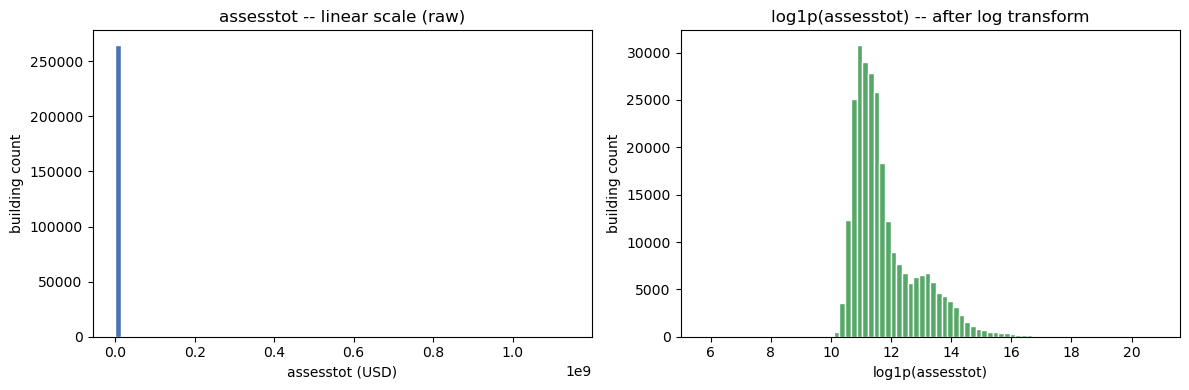

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['assesstot'], bins=80, color='#4c72b0', edgecolor='white')
axes[0].set_title('assesstot -- linear scale (raw)')
axes[0].set_xlabel('assesstot (USD)')
axes[0].set_ylabel('building count')
axes[1].hist(np.log1p(df['assesstot']), bins=80, color='#55a868', edgecolor='white')
axes[1].set_title('log1p(assesstot) -- after log transform')
axes[1].set_xlabel('log1p(assesstot)')
axes[1].set_ylabel('building count')
plt.tight_layout()
plt.show()

### 8.2 Compute extreme-value thresholds

In [19]:
LOWER_Q = 0.005
UPPER_Q = 0.995
lower_thr = df['assesstot'].quantile(LOWER_Q)
upper_thr = df['assesstot'].quantile(UPPER_Q)
print(f'Lower 0.5% threshold: ${lower_thr:>14,.0f}')
print(f'Upper 0.5% threshold: ${upper_thr:>14,.0f}')
print(f'Ratio (upper / lower): {upper_thr / lower_thr:.0f}x')

Lower 0.5% threshold: $        31,320
Upper 0.5% threshold: $     8,641,183
Ratio (upper / lower): 276x


### 8.3 Add the `is_extreme_value` flag

In [20]:
df['is_extreme_value'] = (df['assesstot'] < lower_thr) | (df['assesstot'] > upper_thr)
flag_counts = df['is_extreme_value'].value_counts().to_frame('count')
flag_counts['pct'] = (flag_counts['count'] / len(df) * 100).round(2)
flag_counts

,count,pct
is_extreme_value,,
False,262856,99.0
True,2651,1.0


### 8.4 What do the extreme tails look like?

In [21]:
cheap_cols = ['bbl', 'address', 'bldgclass', 'landuse', 'bldgarea', 'lotarea', 'yearbuilt', 'assesstot']
print('Lower tail -- 5 cheapest surviving buildings:')
print(df.nsmallest(5, 'assesstot')[cheap_cols].to_string(index=False))
print()
print('Upper tail -- 5 highest-assessed surviving buildings:')
print(df.nlargest(5, 'assesstot')[cheap_cols].to_string(index=False))

Lower tail -- 5 cheapest surviving buildings:
         bbl              address bldgclass  landuse  bldgarea  lotarea  yearbuilt  assesstot
3067360072.0 1608 CHESTNUT AVENUE        Z9      NaN     121.0    124.0     1931.0      316.0
3010970047.0       523A 12 STREET        Z9      NaN   13300.0     62.0        NaN      885.0
3003720025.0  187 HAMILTON AVENUE        Q1      9.0      93.0     93.0     1931.0      909.0
3048900037.0        SNYDER AVENUE        Z0      1.0     400.0   1500.0        NaN     1255.0
3088452170.0        2 EATON COURT        Z9      NaN     180.0    540.0        NaN     1335.0

Upper tail -- 5 highest-assessed surviving buildings:
         bbl              address bldgclass  landuse  bldgarea    lotarea  yearbuilt    assesstot
3011180001.0  620 ATLANTIC AVENUE        P9      8.0  660000.0   315943.0     2011.0 1142662050.0
3020230001.0      652 KENT AVENUE        T2      7.0 7058736.0  6429961.0     1958.0  230179050.0
3009020001.0        500 20 STREET        

### 8.5 Decision summary

- Flag, do not drop.
- All regression models in Notebook 06 operate on `np.log1p(assesstot)`.
- The report's *Data Quality* section will describe these thresholds and note that no records were excluded on outlier grounds — a deliberate choice.

## 9. Data Quality Report

**A self-contained narrative of the cleaning pipeline, written to be lifted directly into the final report's *Data Quality* section.**

### 9.1 Inputs and target

The working dataset is built on a single source — **NYC PLUTO 25v4** — restricted to the Brooklyn borough. The raw extract contains **276,324 tax-lot records** across 92 columns, of which **26 are retained as analytically relevant**; the remaining 66 are PLUTO bookkeeping. Full keep/drop justification is in §3 of this notebook.

The regression target is `assesstot`, the NYC Department of Finance's assessed total value. Section 8 documents the principled handling of this target, including the `np.log1p` transform applied at modelling time and the outlier-flagging policy.

### 9.2 Missing-value findings

Five distinct missingness patterns emerged:

| Pattern | Columns | Rows | Resolution |
|---|---|---|---|
| Correlated bad records | `address`, `bldgclass`, `yearbuilt`, `assessland`, `yearalter1`, `exempttot`, `assesstot` | 92 (same rows) | Caught by `assesstot > 0` and `bldgarea > 0` filters |
| Missing coordinates | `latitude`, `longitude` | 480 | Caught by coordinate sanity check |
| Sparse-by-design flood flag | `firm07_flag` | 268,909 (97.3%) | Treated as binary indicator in Notebook 03 |
| Joint commercial / residential sub-area gap | `comarea`, `resarea` | 12,250 | Left as NaN; tree models handle natively |
| Floor-count gap | `numfloors` | 11,041 | NaN for tree models; median-imputed only in linear baseline |

No column exhibits Heavy-bucket missingness (10–50%). The only `>50%` column (`firm07_flag`) is explicitly sparse by design.

### 9.3 Hidden-missing (zero-as-NaN) findings

| Pattern | Rows | Decision |
|---|---|---|
| `bldgarea == 0` (vacant lot) | 10,250 | Dropped — no building present |
| `yearbuilt == 0` | 10,240 | Recoded to `NaN`; 0.94 correlation with `bldgarea == 0` |
| `assesstot == 0` (tax-exempt) | 970 | Dropped — target undefined |
| `lotarea == 0` | 59 | Dropped — corrupt records |
| `unitstotal == 0` | 11,128 | Kept — legitimate non-residential |
| `yearalter1 == 0` | 239,403 | Kept — canonical "never altered" |

### 9.4 Coordinate validity

| Status | Count | Share |
|---|---|---|
| `valid` | 275,844 | 99.83% |
| `null`  | 480 | 0.17% |
| `out_of_bbox` | 0 | 0.00% |

PLUTO's geocoding is internally consistent for Brooklyn.

### 9.5 Audited filter pipeline

| Step | Rule | Rows before | Rows after | Dropped | Cumulative % |
|---|---|---|---|---|---|
| 0 | starting rows | 276,324 | 276,324 | 0 | 0.00% |
| 1 | valid coordinates | 276,324 | 275,844 | 480 | 0.17% |
| 2 | `bldgarea > 0` | 275,844 | 265,629 | 10,215 | 3.87% |
| 3 | `lotarea > 0` | 265,629 | 265,613 | 16 | 3.88% |
| 4 | `assesstot > 0` | 265,613 | 265,507 | 106 | 3.91% |

**Final retention: 265,507 records (96.09%).** A noteworthy property: 94% of the total drop came from a single rule (`bldgarea > 0`), demonstrating that PLUTO's quality problems are **clustered** — vacant lots, tax-exempt records, and lotarea=0 errors largely overlap. The data is not 4% bad in five independent ways; it is 4% bad in one correlated way.

### 9.6 Outlier handling

No records were excluded on outlier grounds. Instead:

- 0.5% / 99.5% percentile thresholds define the `is_extreme_value` flag — applied to **2,651 records (1.00%)** for downstream error analysis.
- Target is log-transformed (`np.log1p`) at modelling time.

Observed range of surviving `assesstot`:

| Statistic | Value |
|---|---|
| Min | \$316 |
| Median | \$93,240 |
| 95th percentile | \$1,234,800 |
| 99th percentile | \$4,607,535 |
| Max | \$1,142,662,000 (Pacific Park / Barclays Center complex, 620 Atlantic Avenue) |

The upper tail contains recognisable Brooklyn landmarks (Barclays Center, Brooklyn Navy Yard, large DUMBO mixed-use developments) — real Brooklyn variance, retained in the training set.

### 9.7 Output handed to downstream notebooks

`data/processed/brooklyn_clean.parquet` — **265,507 rows × 27 columns** (26 retained PLUTO columns plus `is_extreme_value`). This is the canonical input for `03_feature_engineering.ipynb`.

## 10. Save brooklyn_clean.parquet

In [22]:
out_path = PROCESSED_DATA_DIR / 'brooklyn_clean.parquet'
df.to_parquet(out_path, index=False)

print(f'Saved cleaned dataset to: {out_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'File size: {out_path.stat().st_size / 1024**2:.1f} MB')

verify = pd.read_parquet(out_path)
assert verify.shape == df.shape, 'Round-trip parquet shape mismatch'
assert (verify.columns == df.columns).all(), 'Round-trip parquet columns mismatch'
print('Round-trip parquet read-back: OK')

Saved cleaned dataset to: C:\Users\Delfin AKSU\Desktop\urban-building-ml\data\processed\brooklyn_clean.parquet
Shape: 265,507 rows x 27 columns
File size: 12.5 MB
Round-trip parquet read-back: OK


**Proceed to `03_feature_engineering.ipynb`.**

The next notebook will load `brooklyn_clean.parquet`, project all geometries to EPSG:2263, build BallTree spatial indexes, and compute:

- subway-accessibility features (`nearest_subway_dist`, `subway_count_500m`, `subway_count_1000m`)
- per-category POI density features at 500m radius (cafe, restaurant, school, park, supermarket, convenience)
- engineered PLUTO features (`building_age`, `far`, `unit_density`, `commercial_ratio`)
- the binary `firm07_flag` indicator.